In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import json
from scipy.stats import kurtosis, skew
import joblib  # Para salvar e carregar o modelo

In [3]:
# Load the data
train_df = pd.read_csv("archive/Train.csv")
test_df = pd.read_csv("archive/Test.csv")

# Drop the 'Unnamed: 0' column
train_df.drop(['Unnamed: 0'], axis = 1, inplace = True)
test_df.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [4]:
print(f"Training data shape: {train_df.shape}\nTest data shape: {test_df.shape}")

Training data shape: (1428, 11)
Test data shape: (356, 11)


In [41]:
X_train = train_df.drop(['fall','label'],axis=1)
y_train = train_df['fall']
X_test =  test_df.drop(['fall','label'],axis=1)
y_test =  test_df['fall']

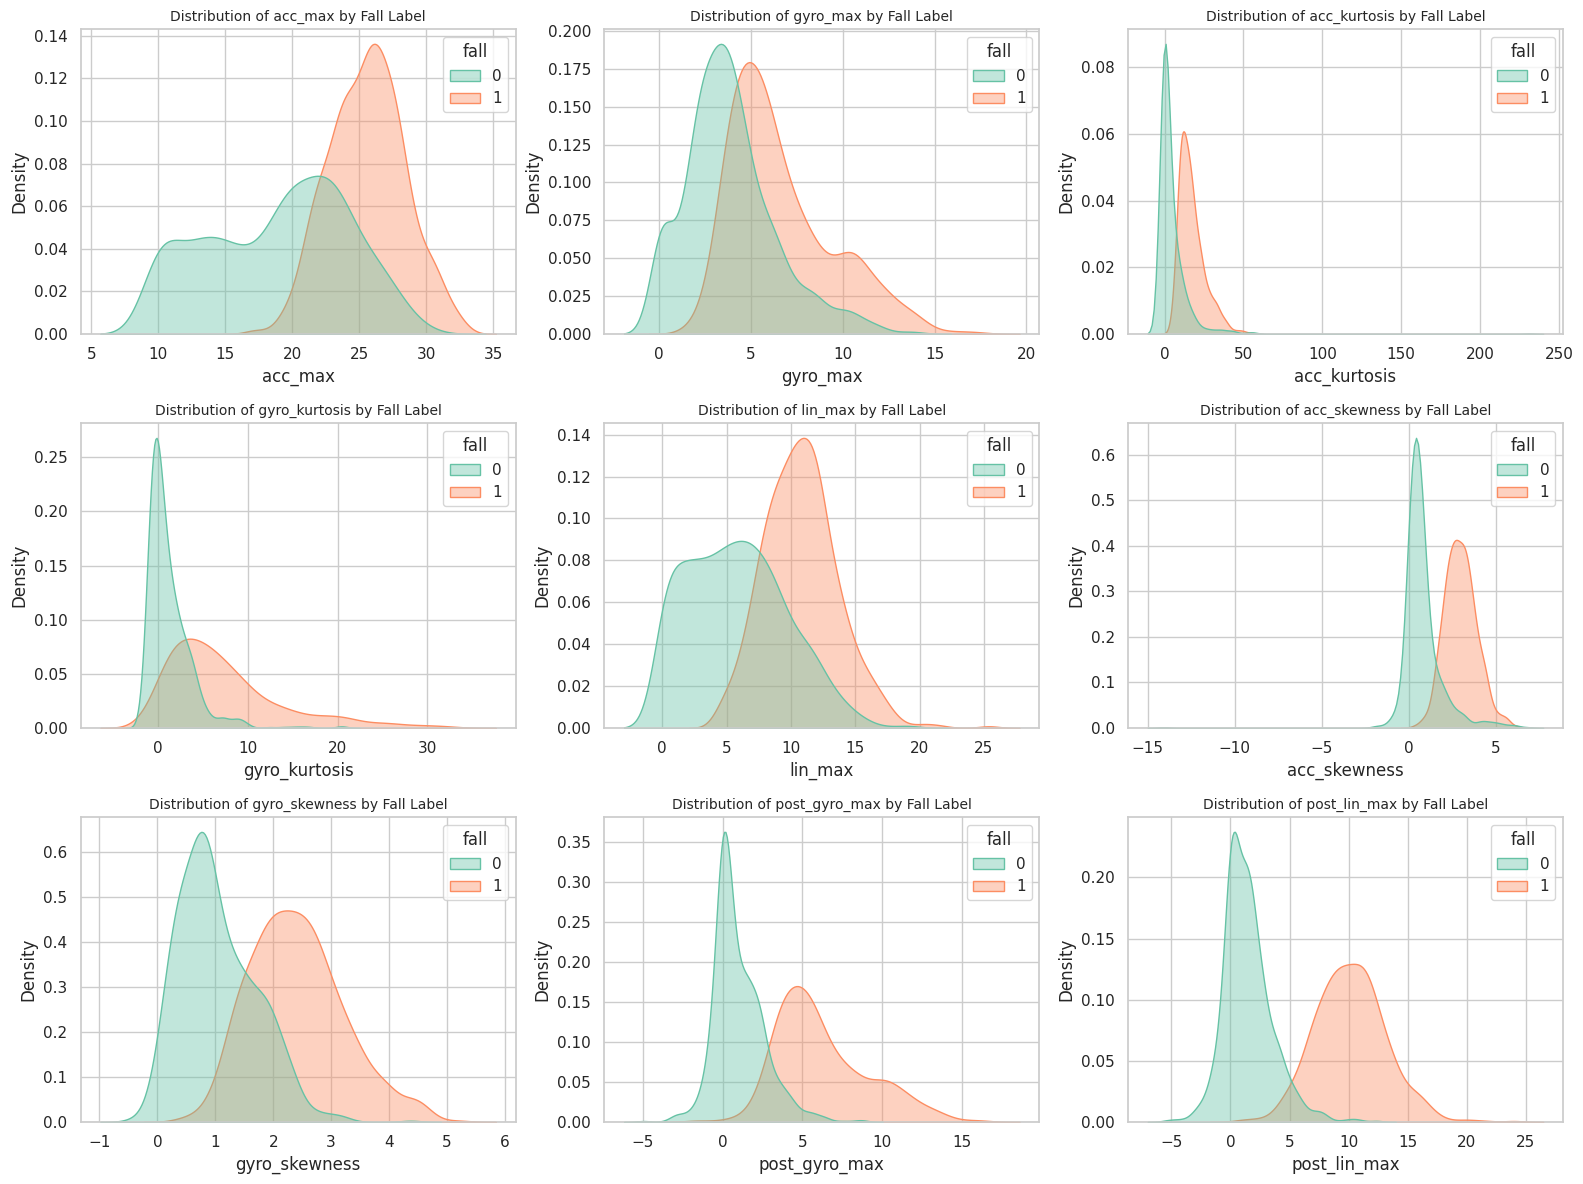

In [42]:
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

n_cols = 3
n_rows = (len(X_train.columns) + n_cols - 1) // n_cols 

for i, column in enumerate(X_train.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(data=X_train, x=column, hue=y_train, fill=True, common_norm=False, alpha=0.4, palette="Set2")
    plt.title(f'Distribution of {column} by Fall Label', fontsize=10)
    plt.xlabel(column)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

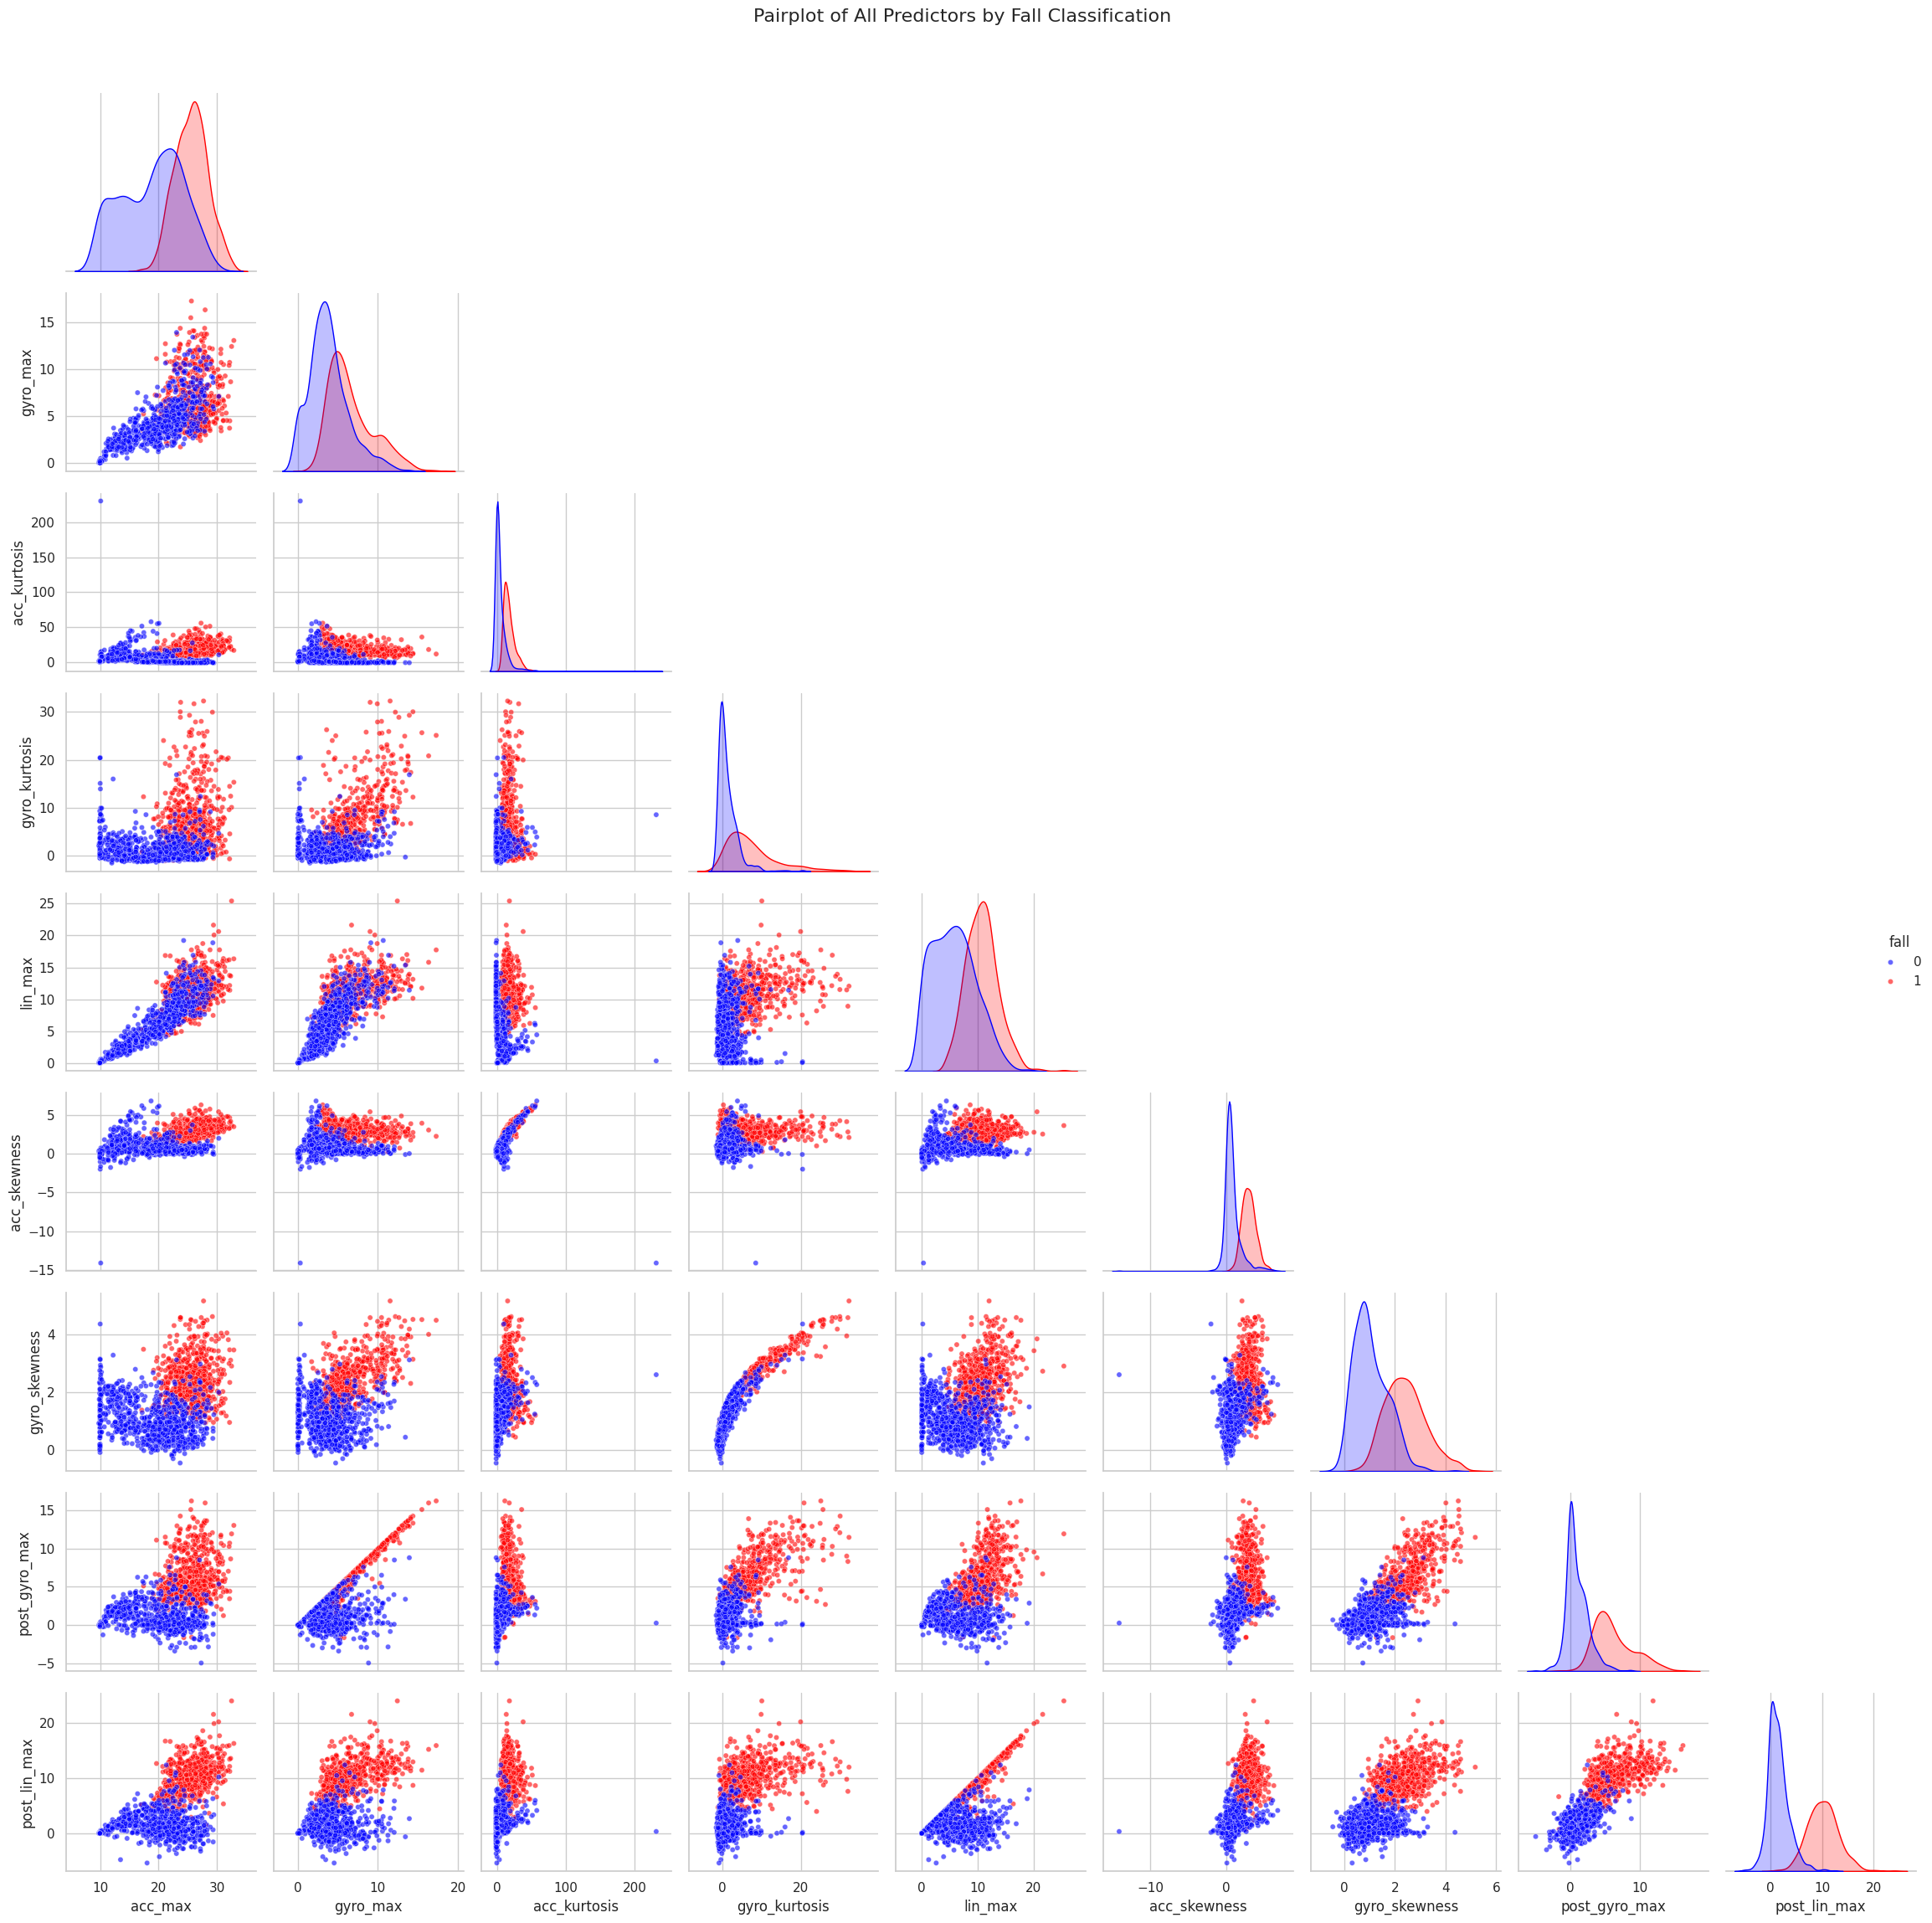

In [43]:
data = X_train.copy()
data['fall'] = y_train

pairplot = sns.pairplot(
    data,
    hue='fall',  
    palette={0: 'blue', 1: 'red'},  
    diag_kind='kde',  
    corner=True,  
    plot_kws={'alpha': 0.6, 's': 20} 
)

pairplot.fig.suptitle("Pairplot of All Predictors by Fall Classification", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
X_train[1]

array([0.75049306, 0.49266508, 0.35236934, 0.25823577, 0.00251875,
       0.85666832, 0.75144965, 0.90134963, 0.50684513])

Training Logistic Regression...


/mnt/c/Users/Jmano/iot_2024/seesafe/treinamento_analise/.venv/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/mnt/c/Users/Jmano/iot_2024/seesafe/treinamento_analise/.venv/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/mnt/c/Users/Jmano/iot_2024/seesafe/treinamento_analise/.venv/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/mnt/c/Users/Jmano/iot_2024/seesafe/treinamento_analise/.venv/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/mnt/c/Users/Jmano/iot_2024/seesafe/treinamento_analise/.venv/lib/python3.8/site-packages/sklearn/li

Training Decision Tree...
Training K-Nearest Neighbors...
Training Random Forest...
Training SVM...


/tmp/ipykernel_1666/3595344996.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')


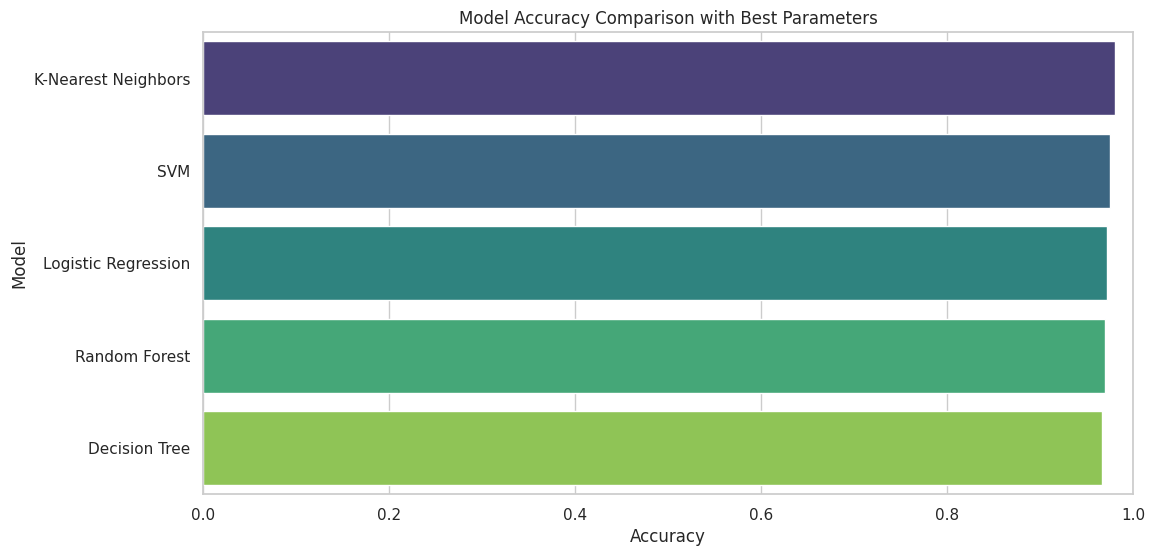


Ranking of Models and Best Parameters:
                 Model  Accuracy  \
2  K-Nearest Neighbors  0.980337   
4                  SVM  0.974719   
0  Logistic Regression  0.971910   
3        Random Forest  0.969101   
1        Decision Tree  0.966292   

                                     Best Parameters  
2  {'metric': 'manhattan', 'n_neighbors': 3, 'wei...  
4        {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}  
0                    {'C': 1, 'solver': 'liblinear'}  
3  {'criterion': 'entropy', 'max_depth': 20, 'min...  
1  {'criterion': 'entropy', 'max_depth': 5, 'min_...  

Classification Reports for All Models:

Model: Logistic Regression
              precision    recall  f1-score    support
0              0.980100  0.970443  0.975248  203.00000
1              0.961290  0.973856  0.967532  153.00000
accuracy       0.971910  0.971910  0.971910    0.97191
macro avg      0.970695  0.972150  0.971390  356.00000
weighted avg   0.972016  0.971910  0.971932  356.00000

Model: Decisio

In [9]:
models_and_params = {
    'Logistic Regression': {
        'model': LogisticRegression(),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100, 1000],
            'solver': ['liblinear', 'lbfgs', 'saga']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'max_depth': [3, 5, 10, 20, None],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 5, 10],
            'criterion': ['gini', 'entropy', 'log_loss']
        }
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [1, 3, 5, 7, 10, 15],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [50, 100, 200, 500],
            'max_depth': [10, 20, 50, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5],
            'criterion': ['gini', 'entropy']
        }
    },
    'SVM': {
        'model': SVC(),
        'params': {
            'C': [0.1, 1, 10, 100, 1000],
            'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
            'gamma': ['scale', 'auto']
        }
    }
}

# Inicializar listas para salvar os resultados
model_names = []
best_accuracies = []
best_params = []
classification_reports = []

# Avaliação de cada modelo com GridSearchCV
for model_name, model_info in models_and_params.items():
    print(f"Training {model_name}...")
    grid = GridSearchCV(estimator=model_info['model'],
                        param_grid=model_info['params'],
                        cv=5,
                        scoring='accuracy',
                        n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Avaliar no conjunto de teste
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Coletar os resultados
    model_names.append(model_name)
    best_accuracies.append(accuracy_score(y_test, y_pred))
    best_params.append(grid.best_params_)
    classification_reports.append(classification_report(y_test, y_pred, output_dict=True))

# Criar um DataFrame para os resultados
results_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': best_accuracies,
    'Best Parameters': best_params
}).sort_values(by='Accuracy', ascending=False)

# Plotar os resultados
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')
plt.title('Model Accuracy Comparison with Best Parameters')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)  # Acurácia varia de 0 a 1
plt.show()

# Exibir os resultados em tabela
print("\nRanking of Models and Best Parameters:")
print(results_df)

print("\nClassification Reports for All Models:")
for i, report in enumerate(classification_reports):
    print(f"\nModel: {model_names[i]}")
    print(pd.DataFrame(report).transpose())


In [10]:
param_grid = {
    'n_neighbors': range(1, 100),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_

In [11]:
print("Melhores hiperparâmetros encontrados:", grid_search.best_params_)

Melhores hiperparâmetros encontrados: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'uniform'}


In [12]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000],           # Valores de regularização
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],  # Diferentes kernels
    'gamma': ['scale', 'auto'],            # Parâmetro gamma
    'degree': [2, 3, 4],                   # Grau do kernel polinomial
    'coef0': [0.0, 0.1, 0.5]               # Constante de ajuste para kernels polinomiais/sigmoid
}

svm = SVC()

grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_svm.fit(X_train, y_train)
best_svm = grid_search_svm.best_estimator_


In [13]:
print("Melhores hiperparâmetros encontrados:", grid_search_svm.best_params_)

Melhores hiperparâmetros encontrados: {'C': 1, 'coef0': 0.5, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}


Comparing Models:

Results for KNN:
Test Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       203
           1       0.96      0.99      0.97       153

    accuracy                           0.98       356
   macro avg       0.98      0.98      0.98       356
weighted avg       0.98      0.98      0.98       356



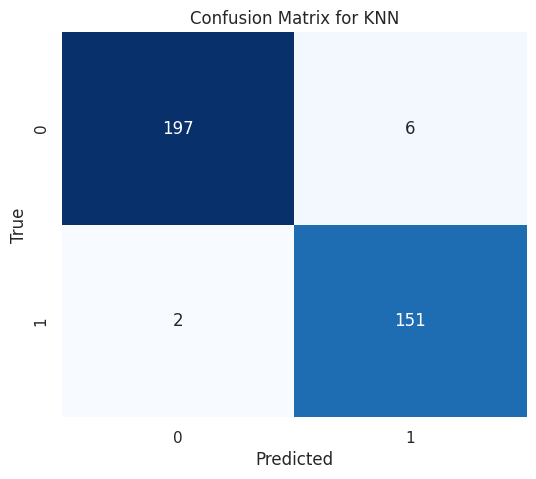

Results for SVM:
Test Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       203
           1       0.94      0.98      0.96       153

    accuracy                           0.97       356
   macro avg       0.96      0.97      0.97       356
weighted avg       0.97      0.97      0.97       356



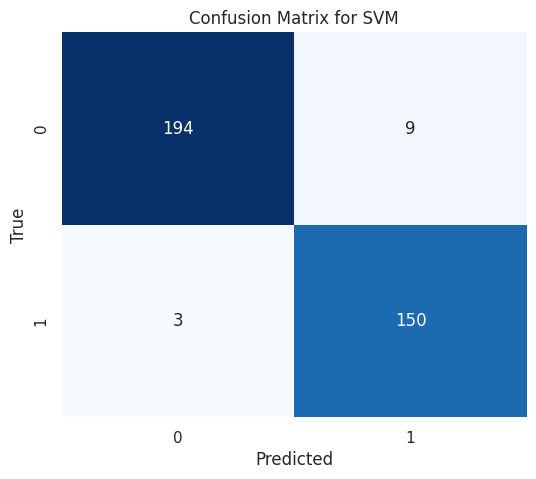


Summary of Model Comparison:
KNN Test Accuracy: 0.98
SVM Test Accuracy: 0.97


In [14]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

print("Comparing Models:\n")

y_pred_knn = best_knn.predict(X_test)
y_pred_svm = best_svm.predict(X_test)

print("Results for KNN:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print(classification_report(y_test, y_pred_knn))
plot_confusion_matrix(y_test, y_pred_knn, "KNN")

print("Results for SVM:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print(classification_report(y_test, y_pred_svm))
plot_confusion_matrix(y_test, y_pred_svm, "SVM")

print("\nSummary of Model Comparison:")
print(f"KNN Test Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print(f"SVM Test Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")

In [15]:
def get_data(file_path):
    # Carrega os dados do JSON
    with open(file_path, 'r') as f:
        data = json.load(f)  
    
    features = []
    
    for device in data:  # Itera sobre cada dispositivo
        sensor_readings = device.get('sensorsReadings', [])

        acc_x, acc_y, acc_z = [], [], []
        gyro_x, gyro_y, gyro_z = [], [], []
        
        for reading in sensor_readings:
            acc_data = reading.get('accelerometerData', {})
            gyro_data = reading.get('gyroscopeData', {})
            
            acc_x.append(acc_data.get('x', 0))
            acc_y.append(acc_data.get('y', 0))
            acc_z.append(acc_data.get('z', 0))
            
            gyro_x.append(gyro_data.get('x', 0))
            gyro_y.append(gyro_data.get('y', 0))
            gyro_z.append(gyro_data.get('z', 0))

        acc_x = np.array(acc_x)
        acc_y = np.array(acc_y)
        acc_z = np.array(acc_z)
        gyro_x = np.array(gyro_x)
        gyro_y = np.array(gyro_y)
        gyro_z = np.array(gyro_z)
    
    return acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z


In [16]:
acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z = get_data('data/sensorsData.json')

In [17]:
def get_features(acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, interval=6):
    acc_x_linear = acc_x - np.mean(acc_x)
    acc_y_linear = acc_y - np.mean(acc_y)
    acc_z_linear = acc_z - np.mean(acc_z)
    linear_acc_magnitude = np.sqrt(acc_x_linear**2 + acc_y_linear**2 + acc_z_linear**2)

    gyro_magnitude = np.sqrt(gyro_x**2 + gyro_y**2 + gyro_z**2)

    features = []

    for start in range(0, len(linear_acc_magnitude), interval):
        end = start + interval

        acc_mag_segment = linear_acc_magnitude[start:end]
        gyro_mag_segment = gyro_magnitude[start:end]

        if len(acc_mag_segment) == 0 or len(gyro_mag_segment) == 0:
            continue  

        acc_max = np.max(acc_mag_segment)
        gyro_max = np.max(gyro_mag_segment)
        acc_kurtosis = kurtosis(acc_mag_segment, fisher=True, bias=False) if len(acc_mag_segment) > 1 else 0
        gyro_kurtosis = kurtosis(gyro_mag_segment, fisher=True, bias=False) if len(gyro_mag_segment) > 1 else 0
        acc_skewness = skew(acc_mag_segment, bias=False) if len(acc_mag_segment) > 1 else 0
        gyro_skewness = skew(gyro_mag_segment, bias=False) if len(gyro_mag_segment) > 1 else 0

        segment_fraction = max(1, len(acc_mag_segment) // 5)
        post_lin_max = np.max(acc_mag_segment[-segment_fraction:]) if segment_fraction > 0 else 0
        post_gyro_max = np.max(gyro_mag_segment[-segment_fraction:]) if segment_fraction > 0 else 0

        features.append([
            acc_max,
            gyro_max,
            acc_kurtosis,
            gyro_kurtosis,
            acc_skewness,
            gyro_skewness,
            np.max(acc_mag_segment),  # linear acc max
            post_lin_max,
            post_gyro_max
        ])

    return np.array(features)


In [18]:
features = get_features(acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z)

In [19]:
X = np.array(features)

scaler.fit(X)
X = scaler.transform(X)

predict_knn = best_knn.predict(X)
predict_svm = best_svm.predict(X)
print(f"Predictions with KNN: {predict_knn}")
print(f"Predictions with SVM: {predict_svm}")


Predictions with KNN: [0 0 1 1]
Predictions with SVM: [0 0 1 1]


In [20]:
acceleration_coletado = pd.read_csv("data/acceleration_data_02.csv")
angular_velocity_coletado = pd.read_csv("data/angular_velocity_data_02.csv")

In [21]:
acceleration_coletado

,Timestamp,X,Y,Z
0,26-Jan-2025 14:20:42.972,-0.852336,4.740520,9.327810
1,26-Jan-2025 14:20:42.980,-0.809240,4.723760,9.677363
2,26-Jan-2025 14:20:42.988,-0.596156,4.709395,9.868899
3,26-Jan-2025 14:20:42.996,-0.536301,4.733337,9.842564
4,26-Jan-2025 14:20:43.004,-0.567426,4.759673,9.720459
...,...,...,...,...
14890,26-Jan-2025 14:24:37.416,0.517148,2.035071,8.966286
14891,26-Jan-2025 14:24:37.424,0.814029,1.865083,8.853758
14892,26-Jan-2025 14:24:37.432,0.660800,1.817199,8.923190
14893,26-Jan-2025 14:24:37.440,0.732626,1.757344,9.045294


In [22]:
angular_velocity_coletado

,Timestamp,X,Y,Z
0,26-Jan-2025 14:20:42.993,0.105069,-0.307265,-0.112399
1,26-Jan-2025 14:20:43.009,0.323148,-0.428217,-0.101404
2,26-Jan-2025 14:20:43.025,0.359800,-0.397673,-0.075136
3,26-Jan-2025 14:20:43.041,0.274889,-0.237627,-0.067195
4,26-Jan-2025 14:20:43.057,0.238237,-0.007941,-0.155771
...,...,...,...,...
14599,26-Jan-2025 14:24:37.372,0.260229,-0.182649,-0.775799
14600,26-Jan-2025 14:24:37.388,0.255953,-0.199753,-0.726319
14601,26-Jan-2025 14:24:37.405,0.020159,-0.352469,-0.651182
14602,26-Jan-2025 14:24:37.421,-0.163712,-0.289550,-0.477697


In [23]:
def plot_time_series(acceleration, angular_velocity):
    acceleration['Timestamp'] = pd.to_datetime(acceleration['Timestamp'])
    angular_velocity['Timestamp'] = pd.to_datetime(angular_velocity['Timestamp'])
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(acceleration['Timestamp'], acceleration['X'], label='Acceleration X', color='r')
    axes[0].plot(acceleration['Timestamp'], acceleration['Y'], label='Acceleration Y', color='g')
    axes[0].plot(acceleration['Timestamp'], acceleration['Z'], label='Acceleration Z', color='b')
    axes[0].set_title('Acceleration Time Series')
    axes[0].set_ylabel('Acceleration (m/s^2)')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(angular_velocity['Timestamp'], angular_velocity['X'], label='Angular Velocity X', color='r')
    axes[1].plot(angular_velocity['Timestamp'], angular_velocity['Y'], label='Angular Velocity Y', color='g')
    axes[1].plot(angular_velocity['Timestamp'], angular_velocity['Z'], label='Angular Velocity Z', color='b')
    axes[1].set_title('Angular Velocity Time Series')
    axes[1].set_ylabel('Angular Velocity (rad/s)')
    axes[1].set_xlabel('Time')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

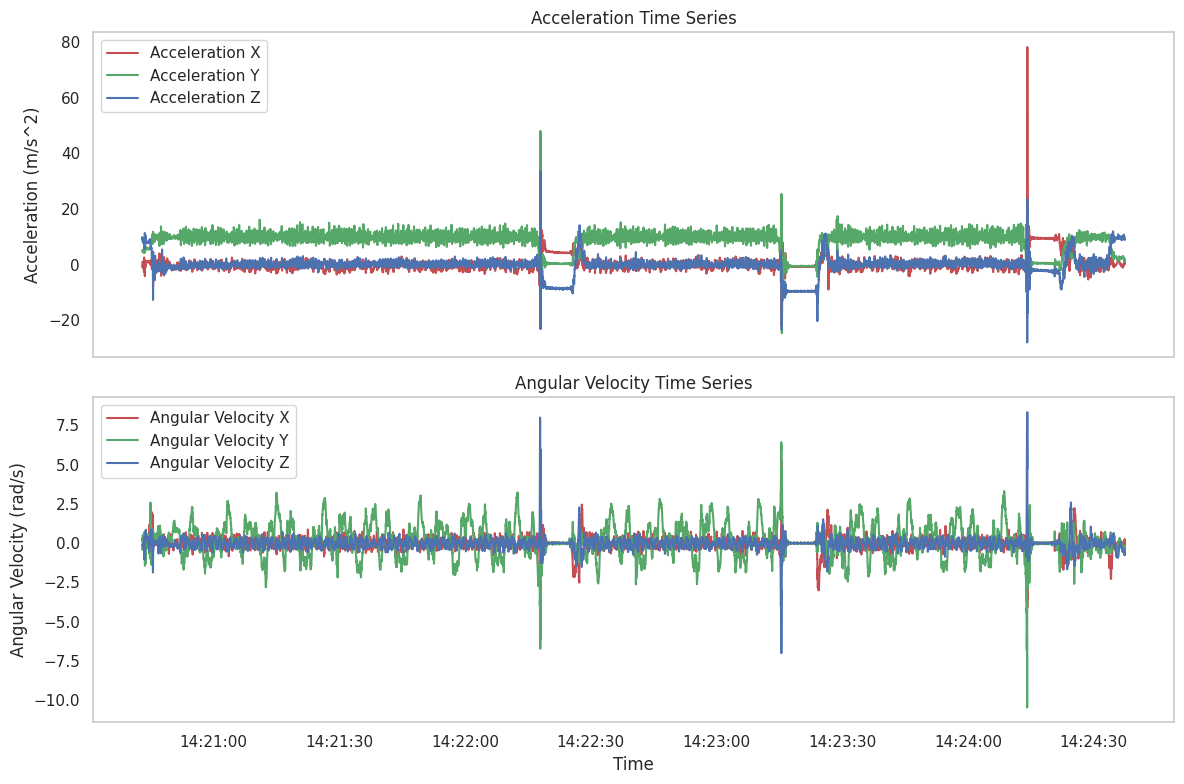

In [24]:
plot_time_series(acceleration_coletado, angular_velocity_coletado)

In [25]:
nearest_indices = angular_velocity_coletado.index.map(
    lambda t: np.argmin(np.abs(acceleration_coletado.index - t))
)

angular_velocity_coletado['nearest_acc_timestamp'] = acceleration_coletado.index[nearest_indices]

combined_data = angular_velocity_coletado.join(acceleration_coletado, on='nearest_acc_timestamp', rsuffix='_acc')
combined_data.rename(columns={'X': 'X_gyro', 'Y': 'Y_gyro', 'Z': 'Z_gyro'}, inplace=True)
combined_data.drop('nearest_acc_timestamp', axis=1, inplace=True)
combined_data

,Timestamp,X_gyro,Y_gyro,Z_gyro,Timestamp_acc,X_acc,Y_acc,Z_acc
0,2025-01-26 14:20:42.993,0.105069,-0.307265,-0.112399,2025-01-26 14:20:42.972,-0.852336,4.740520,9.327810
1,2025-01-26 14:20:43.009,0.323148,-0.428217,-0.101404,2025-01-26 14:20:42.980,-0.809240,4.723760,9.677363
2,2025-01-26 14:20:43.025,0.359800,-0.397673,-0.075136,2025-01-26 14:20:42.988,-0.596156,4.709395,9.868899
3,2025-01-26 14:20:43.041,0.274889,-0.237627,-0.067195,2025-01-26 14:20:42.996,-0.536301,4.733337,9.842564
4,2025-01-26 14:20:43.057,0.238237,-0.007941,-0.155771,2025-01-26 14:20:43.004,-0.567426,4.759673,9.720459
...,...,...,...,...,...,...,...,...
14599,2025-01-26 14:24:37.372,0.260229,-0.182649,-0.775799,2025-01-26 14:24:33.654,-0.682347,10.278308,0.541090
14600,2025-01-26 14:24:37.388,0.255953,-0.199753,-0.726319,2025-01-26 14:24:33.670,-0.476446,10.065224,-0.263362
14601,2025-01-26 14:24:37.405,0.020159,-0.352469,-0.651182,2025-01-26 14:24:33.686,-0.900220,9.892841,0.833182
14602,2025-01-26 14:24:37.421,-0.163712,-0.289550,-0.477697,2025-01-26 14:24:33.702,-0.644040,9.756371,3.038242


In [26]:
features_coletado = get_features(combined_data["X_acc"],combined_data["Y_acc"], combined_data["Z_acc"], combined_data["X_gyro"], combined_data["Y_gyro"], combined_data["Z_gyro"], 400)
features_coletado

array([[ 1.50837671e+01,  3.53474679e+00, -9.75175261e-01,
         5.11974303e+00, -6.29073416e-01,  2.17426432e+00,
         1.50837671e+01,  5.72220150e+00,  9.17821794e-01],
       [ 6.21696321e+00,  2.32879924e+00,  5.94742367e+00,
         6.87412625e-01,  1.74356937e+00,  9.11926063e-01,
         6.21696321e+00,  4.14795570e+00,  2.32879924e+00],
       [ 5.36225574e+00,  2.00005363e+00, -1.27256888e-01,
         1.46261138e-01,  5.60345421e-01,  6.56114493e-01,
         5.36225574e+00,  4.72578136e+00,  9.42553872e-01],
       [ 5.77904408e+00,  2.70538363e+00,  6.35193282e-01,
         1.31686362e-01,  7.73966961e-01,  9.05751085e-01,
         5.77904408e+00,  5.03213911e+00,  1.90682645e+00],
       [ 7.77238767e+00,  3.26345149e+00,  1.49431734e+00,
         1.05787092e+00,  8.84480943e-01,  1.08304691e+00,
         7.77238767e+00,  7.77238767e+00,  3.26345149e+00],
       [ 5.50346690e+00,  2.82242083e+00, -4.61813330e-01,
        -2.38236676e-01,  2.02688673e-01,  5.344283

In [27]:
X_coletado = np.array(features_coletado)

scaler2 = StandardScaler()
scaler2.fit(X_coletado)
X_coletado = scaler2.transform(X_coletado)

predicoes_coletado_knn = best_knn.predict(X_coletado)
predicoes_coletado_svm = best_svm.predict(X_coletado)


In [28]:
combined_data

,Timestamp,X_gyro,Y_gyro,Z_gyro,Timestamp_acc,X_acc,Y_acc,Z_acc
0,2025-01-26 14:20:42.993,0.105069,-0.307265,-0.112399,2025-01-26 14:20:42.972,-0.852336,4.740520,9.327810
1,2025-01-26 14:20:43.009,0.323148,-0.428217,-0.101404,2025-01-26 14:20:42.980,-0.809240,4.723760,9.677363
2,2025-01-26 14:20:43.025,0.359800,-0.397673,-0.075136,2025-01-26 14:20:42.988,-0.596156,4.709395,9.868899
3,2025-01-26 14:20:43.041,0.274889,-0.237627,-0.067195,2025-01-26 14:20:42.996,-0.536301,4.733337,9.842564
4,2025-01-26 14:20:43.057,0.238237,-0.007941,-0.155771,2025-01-26 14:20:43.004,-0.567426,4.759673,9.720459
...,...,...,...,...,...,...,...,...
14599,2025-01-26 14:24:37.372,0.260229,-0.182649,-0.775799,2025-01-26 14:24:33.654,-0.682347,10.278308,0.541090
14600,2025-01-26 14:24:37.388,0.255953,-0.199753,-0.726319,2025-01-26 14:24:33.670,-0.476446,10.065224,-0.263362
14601,2025-01-26 14:24:37.405,0.020159,-0.352469,-0.651182,2025-01-26 14:24:33.686,-0.900220,9.892841,0.833182
14602,2025-01-26 14:24:37.421,-0.163712,-0.289550,-0.477697,2025-01-26 14:24:33.702,-0.644040,9.756371,3.038242


In [29]:
def plot_time_series_with_predictions(combined_data, predictions):
    import matplotlib.pyplot as plt
    import pandas as pd

    num_intervals = len(predictions)
    if num_intervals > len(combined_data):
        raise ValueError("O número de previsões excede o tamanho dos dados.")

    timestamps = combined_data['Timestamp']
    interval_size = len(combined_data) // num_intervals
    prediction_intervals = [
        (timestamps.iloc[i * interval_size], timestamps.iloc[min((i + 1) * interval_size, len(timestamps)) - 1])
        for i in range(num_intervals)
    ]

    prediction_column = pd.Series(index=combined_data.index, dtype=int)
    for i, (start, end) in enumerate(prediction_intervals):
        mask = (combined_data['Timestamp'] >= start) & (combined_data['Timestamp'] <= end)
        prediction_column.loc[mask] = predictions[i]

    combined_data = combined_data.copy()
    combined_data['Prediction'] = prediction_column

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(combined_data['Timestamp'], combined_data['X_acc'], label='Acceleration X', color='r')
    axes[0].plot(combined_data['Timestamp'], combined_data['Y_acc'], label='Acceleration Y', color='g')
    axes[0].plot(combined_data['Timestamp'], combined_data['Z_acc'], label='Acceleration Z', color='b')
    axes[0].set_title('Acceleration Time Series')
    axes[0].set_ylabel('Acceleration (m/s^2)')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(combined_data['Timestamp'], combined_data['X_gyro'], label='Angular Velocity X', color='r')
    axes[1].plot(combined_data['Timestamp'], combined_data['Y_gyro'], label='Angular Velocity Y', color='g')
    axes[1].plot(combined_data['Timestamp'], combined_data['Z_gyro'], label='Angular Velocity Z', color='b')

    fall_predictions = combined_data[combined_data['Prediction'] == 1]
    axes[1].scatter(
        fall_predictions['Timestamp'],
        [combined_data[['X_gyro', 'Y_gyro', 'Z_gyro']].max().max()] * len(fall_predictions),
        color='orange',
        label='Predicted Falls',
        marker='o',
    )

    axes[1].set_title('Angular Velocity Time Series with Predictions')
    axes[1].set_ylabel('Angular Velocity (rad/s)')
    axes[1].set_xlabel('Timestamp')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()


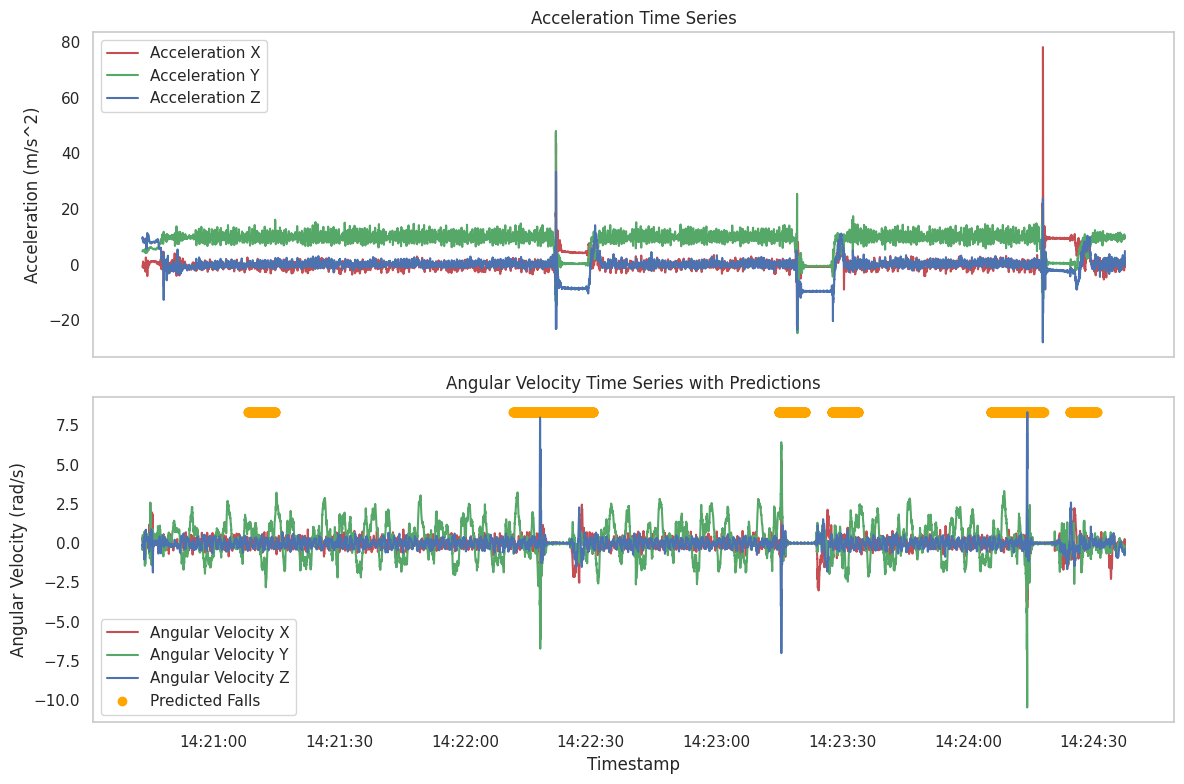

In [30]:
plot_time_series_with_predictions(combined_data, predicoes_coletado_knn)

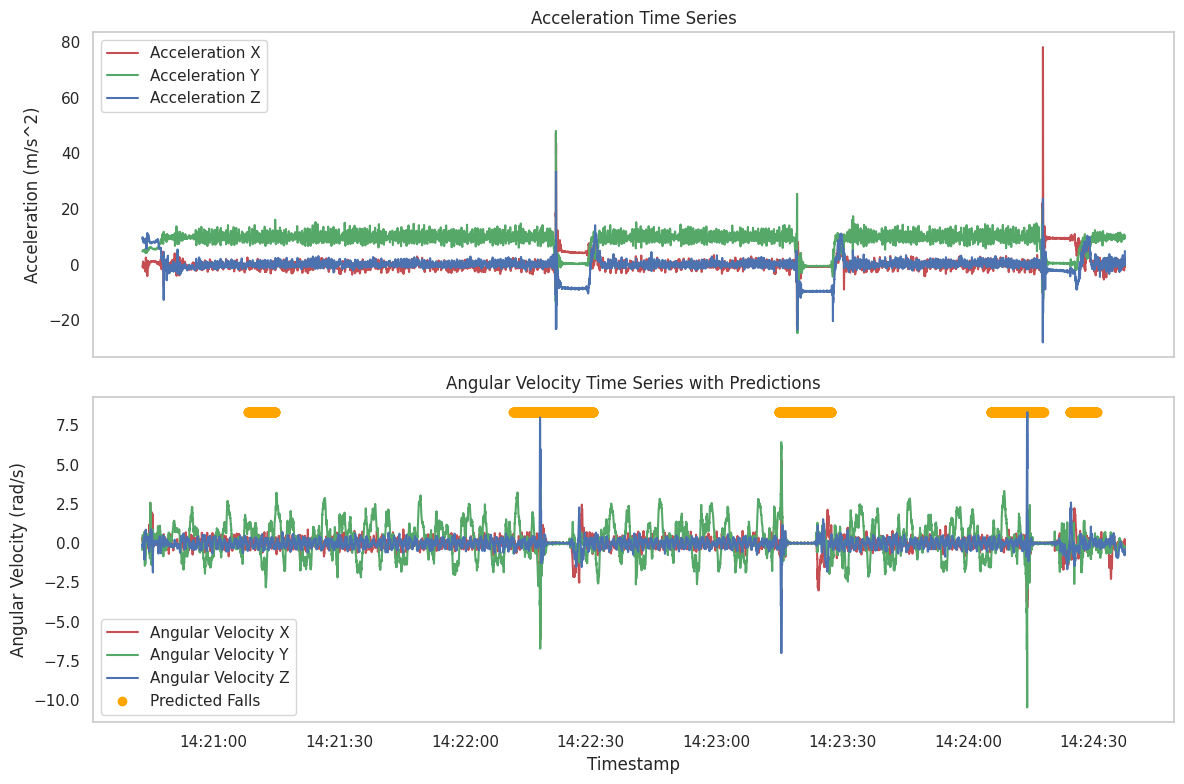

In [31]:
plot_time_series_with_predictions(combined_data, predicoes_coletado_svm)

In [32]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(best_knn, "knn_model.pkl")
joblib.dump(best_svm, "svm_model.pkl")

['svm_model.pkl']

In [39]:
scaler.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8'], dtype=object)